In [1]:
import pandas as pd
import numpy as np

# Load your AMCAT dataset into a Pandas DataFrame (we usually call it 'df')
df = pd.read_csv('data/amcat_data.csv')

# The .head() command tells Pandas to print the first 5 rows to the screen
df.head()

,Unnamed: 0,ID,Salary,DOJ,DOL,Designation,JobCity,Gender,DOB,10percentage,...,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience
0,train,203097,420000.0,01-06-2012 00:00,present,senior quality engineer,Bangalore,f,19-02-1990 00:00,84.3,...,-1,-1,-1,-1,-1,0.9737,0.8128,0.5269,1.35490,-0.4455
1,train,579905,500000.0,01-09-2013 00:00,present,assistant manager,Indore,m,04-10-1989 00:00,85.4,...,-1,-1,-1,-1,-1,-0.7335,0.3789,1.2396,-0.10760,0.8637
2,train,810601,325000.0,01-06-2014 00:00,present,systems engineer,Chennai,f,03-08-1992 00:00,85.0,...,-1,-1,-1,-1,-1,0.2718,1.7109,0.1637,-0.86820,0.6721
3,train,267447,1100000.0,01-07-2011 00:00,present,senior software engineer,Gurgaon,m,05-12-1989 00:00,85.6,...,-1,-1,-1,-1,-1,0.0464,0.3448,-0.3440,-0.40780,-0.9194
4,train,343523,200000.0,01-03-2014 00:00,01-03-2015 00:00,get,Manesar,m,27-02-1991 00:00,78.0,...,-1,-1,-1,-1,-1,-0.8810,-0.2793,-1.0697,0.09163,-0.1295


In [2]:
# --- CELL 2: FIND MISSING VALUES ---
# Let's see exactly how many blank spaces (nulls) are in your dataset
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Unnamed: 0               0
ID                       0
Salary                   0
DOJ                      0
DOL                      0
Designation              0
JobCity                  0
Gender                   0
DOB                      0
10percentage             0
10board                  0
12graduation             0
12percentage             0
12board                  0
CollegeID                0
CollegeTier              0
Degree                   0
Specialization           0
collegeGPA               0
CollegeCityID            0
CollegeCityTier          0
CollegeState             0
GraduationYear           0
English                  0
Logical                  0
Quant                    0
Domain                   0
ComputerProgramming      0
ElectronicsAndSemicon    0
ComputerScience          0
MechanicalEngg           0
ElectricalEngg           0
TelecomEngg              0
CivilEngg                0
conscientiousness        0
agreeableness          

In [3]:
# --- CELL 3: THE REAL CLEANUP ---
# First, we tell Pandas that -1 actually means "Missing" (NaN)
df = df.replace(-1, np.nan)

# Now we fill those gaps with the median (the average middle score)
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Trap avoided! Data is now completely cleaned.")

Trap avoided! Data is now completely cleaned.


Matplotlib is building the font cache; this may take a moment.


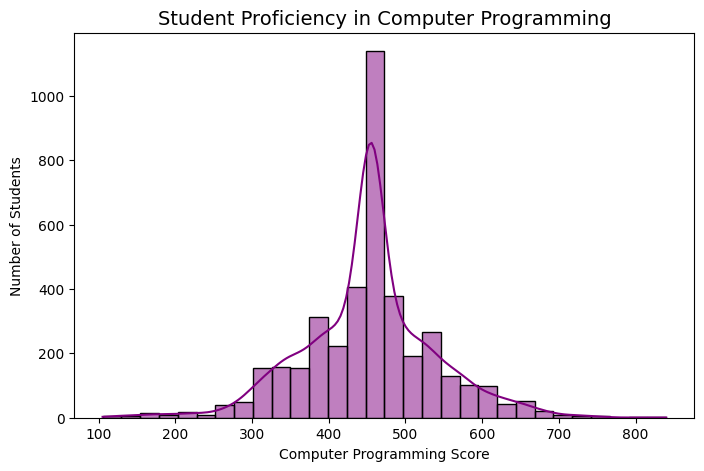

In [4]:
# --- CELL 4: THE DISTRIBUTION GRAPH ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# This draws a histogram of all the Computer Programming scores
sns.histplot(df['ComputerProgramming'], bins=30, kde=True, color='purple')

plt.title("Student Proficiency in Computer Programming", fontsize=14)
plt.xlabel("Computer Programming Score")
plt.ylabel("Number of Students")
plt.show()


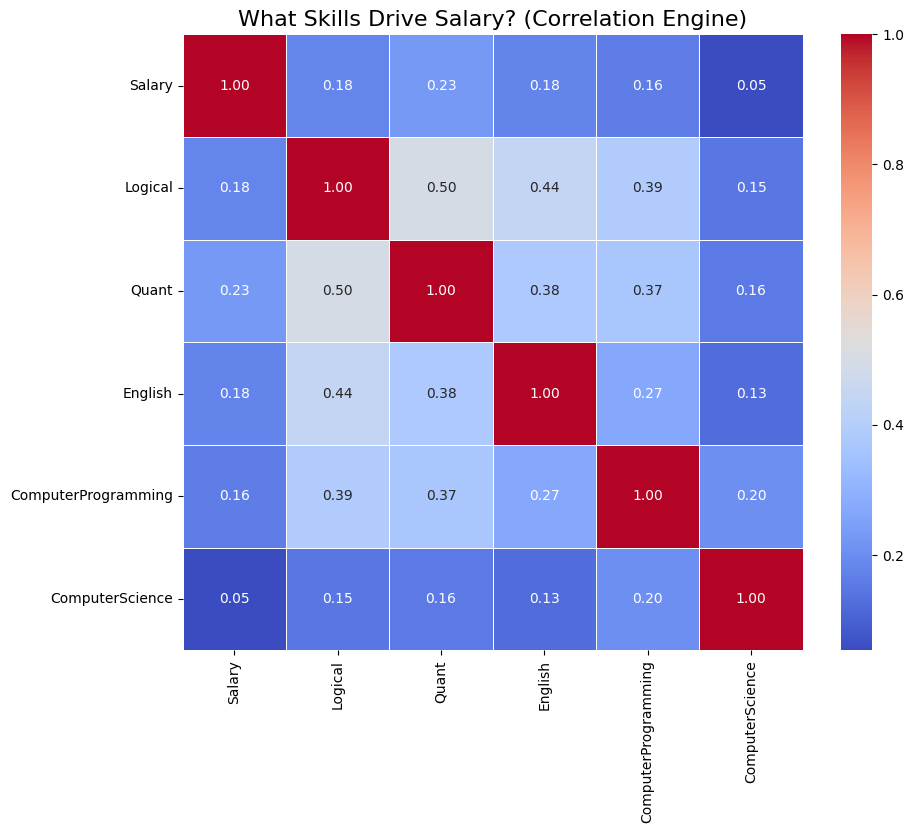

In [5]:
# --- CELL 5: THE CORRELATION HEATMAP ---
import matplotlib.pyplot as plt
import seaborn as sns

# Let's pick the exact columns we care about for Job Readiness
target_columns = ['Salary', 'Logical', 'Quant', 'English', 'ComputerProgramming', 'ComputerScience']

# Filter the dataset to only include these specific columns
subset_df = df[target_columns]

plt.figure(figsize=(10, 8))

# Calculate the correlation math and draw the map
# annot=True puts the actual numbers inside the squares
sns.heatmap(subset_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("What Skills Drive Salary? (Correlation Engine)", fontsize=16)
plt.show()

In [7]:
# --- SAVE THE CLEAN DATA ---
# This takes the 'df' we just cleaned and saves it as a real file in your folder
df.to_csv('data/amcat_data_CLEANED.csv', index=False)
print(" Cleaned data successfully saved!")

 Cleaned data successfully saved!


In [10]:
# --- CELL 7: THE RANDOM FOREST UPGRADE (Matches PPT) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Keep the Feature Engineering! (This is the secret sauce)
clean_df['Total_Aptitude'] = clean_df['Logical'] + clean_df['Quant'] + clean_df['English']

# 2. Update our features list to include our new Super Feature
features = ['Logical', 'Quant', 'English', 'ComputerProgramming', 'Total_Aptitude']
X = clean_df[features]
y = clean_df['Highly_Employable']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Highly Tuned Random Forest (Matching your PPT!)
rf_model_final = RandomForestClassifier(
    n_estimators=200,          # 200 trees for better voting
    max_depth=8,               # Prevent overthinking
    class_weight='balanced',   # Handle the salary imbalance
    random_state=42
)

rf_model_final.fit(X_train, y_train)

# Test the new accuracy!
predictions = rf_model_final.predict(X_test)
final_accuracy = accuracy_score(y_test, predictions)

print(f"Final Tuned Accuracy (Random Forest): {round(final_accuracy * 100, 2)}% ")

Final Tuned Accuracy (Random Forest): 66.0% 
